# Memory Encoding, Suppression, and Homeostatic Rescue
## Three-day protocol — four conditions

**All conditions share identical Day 1 (encoding). Conditions diverge only on Days 2–3:**

| Condition | Synaptic noise (dW) | Excitability OU (ε_i) |
|-----------|--------------------|-----------------------|
| Baseline  | no | no |
| A         | yes | no |
| B         | no | yes |
| C         | yes | yes |

**Day 2**: I = I_p < 0, homeostasis OFF  
**Day 3**: I = I_p stays, homeostasis ON — h(t) fights against suppression

In [21]:
import sys, os
from pathlib import Path
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

sys.path.insert(0, '../src')
from network import HebbianNetwork

DEVICE = 'cpu'
torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = Path('../data')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# --- Model parameters ---
N        = 10
dt       = 10.0    # ms
tau_r    = 10.0    # ms
tau_W    = 2000.0  # ms
tau_h    = 500.0   # ms
eta      = 0.005
lam      = 0.1
kappa_h  = 0.2     # increased to overcome I_p = -3
m_target = 0.5
W_scale  = 0.1

PARAMS = dict(N=N, dt=dt, tau_r=tau_r, tau_W=tau_W, tau_h=tau_h,
              eta=eta, lam=lam, kappa_h=kappa_h, m_target=m_target,
              W_scale=W_scale, seed=42, device=DEVICE)

# --- Simulation lengths ---
T_DAY1    = 2000   # 20 s
T_DAY2    = 2000   # 20 s
T_DAY3    = 2000   # 20 s
REC_EVERY = 10     # record every 100 ms

# --- Condition parameters ---
NOISE_STD = 0.01   # synaptic noise (conditions A, C)
TAU_EPS   = 1000.0 # ms  — slow OU timescale
SIGMA_EPS = 0.8    # OU amplitude (conditions B, C)

print('Parameters set. dt/tau_r =', dt/tau_r)

Parameters set. dt/tau_r = 1.0


In [22]:
# Load or create I_base
try:
    I_base_np = np.load(DATA_DIR / 'I_base.npy')
    I_base = torch.tensor(I_base_np, dtype=torch.float32)
    print('Loaded I_base:', I_base_np)
except FileNotFoundError:
    indices_active = [0, 3, 4, 5, 7]
    amplitudes     = [1.2, 0.85, 1.48, 1.1, 0.95]
    I_base_np = np.zeros(N, dtype=np.float32)
    for i, amp in zip(indices_active, amplitudes):
        I_base_np[i] = amp
    I_base = torch.tensor(I_base_np, dtype=torch.float32)
    DATA_DIR.mkdir(exist_ok=True)
    np.save(DATA_DIR / 'I_base.npy', I_base_np)
    print('Created I_base:', I_base_np)

I_p = -3.0 * torch.ones(N, dtype=torch.float32)

# I_p: uniform suppressive perturbation following OU around MU_P
# Represents slowly fluctuating inhibitory drive (e.g. anesthesia)
MU_P    = -3.0   # mean suppression
TAU_P   = 500.0  # ms — fluctuation timescale
SIGMA_P = 0.2    # amplitude of fluctuations

Loaded I_base: [0.84608525 0.         0.         1.3208548  1.0877894  1.4817168
 0.         1.3395482  0.         0.        ]


In [23]:
# ============================================================
# DAY 1 — Memory Encoding  (shared across all conditions)
# ============================================================
net = HebbianNetwork(**PARAMS)
W_struct_np = net.W_struct.cpu().numpy().copy()

r_d1_hist  = []
W_d1_snaps = {}  # snapshots at 0s, ~7s, ~13s, 20s
snap_steps = {0: '0 s', T_DAY1//3: '7 s', 2*T_DAY1//3: '13 s', T_DAY1-1: '20 s'}

for t in tqdm(range(T_DAY1), desc='Day 1 encoding'):
    if t in snap_steps:
        W_d1_snaps[t] = net.W.cpu().numpy().copy()
    net.step(I_base, noise_std=0.0, homeostasis=False)
    if t % REC_EVERY == 0:
        r_d1_hist.append(net.r.cpu().numpy().copy())

r_d1_hist  = np.array(r_d1_hist)   # (150, 10)
r_m        = net.r.clone()          # memory reference pattern
W_d1       = net.W.clone()          # weights after encoding
r_d1_final = net.r.clone()
dW_d1_np   = W_d1.cpu().numpy() - W_struct_np

print(f'Day 1 done.')
print(f'  r_m mean = {r_m.mean():.3f},  max = {r_m.max():.3f}')
print(f'  ΔW max   = {dW_d1_np.max():.4f}')

Day 1 encoding:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 1 done.
  r_m mean = 0.773,  max = 1.890
  ΔW max   = 0.0840


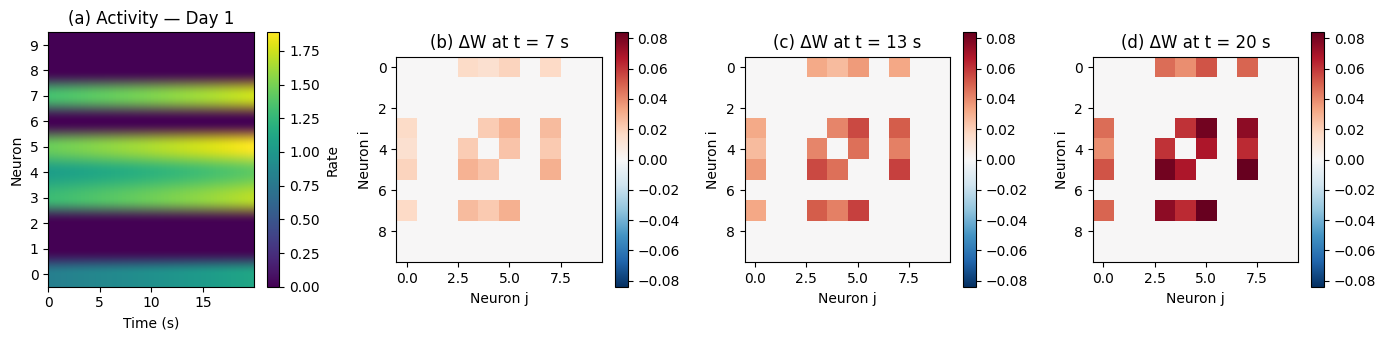

Saved fig_report1.png


In [24]:
# ============================================================
# fig_report1: Day 1 dynamics
# (a) neuron activity heatmap   (b-d) ΔW at t=5s, 10s, 15s
# ============================================================
%matplotlib inline
t_d1 = np.arange(len(r_d1_hist)) * REC_EVERY * dt / 1000.0

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

im0 = axes[0].imshow(r_d1_hist.T, aspect='auto', origin='lower',
                     extent=[0, t_d1[-1], -0.5, N-0.5],
                     cmap='viridis', vmin=0, vmax=r_d1_hist.max())
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Neuron')
axes[0].set_yticks(range(N))
axes[0].set_title('(a) Activity — Day 1')
plt.colorbar(im0, ax=axes[0], label='Rate')

snap_items = [(T_DAY1//3, '7 s'), (2*T_DAY1//3, '13 s'), (T_DAY1-1, '20 s')]
vmax_dW = max(abs(W_d1_snaps[T_DAY1-1] - W_struct_np).max(), 0.005)
for ax_idx, (snap_t, tlabel) in enumerate(snap_items, start=1):
    dW = W_d1_snaps[snap_t] - W_struct_np
    im = axes[ax_idx].imshow(dW, cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    axes[ax_idx].set_title(f'({"bcd"[ax_idx-1]}) \u0394W at t = {tlabel}')
    axes[ax_idx].set_xlabel('Neuron j')
    axes[ax_idx].set_ylabel('Neuron i')
    plt.colorbar(im, ax=axes[ax_idx])

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_report1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_report1.png')

In [25]:
# ============================================================
# Run all four conditions: Days 2 and 3
# All start from the same W_d1, r_d1_final
# ============================================================
CONDITIONS = {
    'Baseline':  {'noise_std': 0.0,       'use_eps': False, 'color': 'black',      'ls': '-'},
    'A: noise':  {'noise_std': NOISE_STD,  'use_eps': False, 'color': 'tab:blue',   'ls': '--'},
    'B: excit.': {'noise_std': 0.0,        'use_eps': True,  'color': 'tab:orange', 'ls': '-.'},
    'C: both':   {'noise_std': NOISE_STD,  'use_eps': True,  'color': 'tab:red',    'ls': ':'},
}

r_m_np   = r_m.cpu().numpy()
r_m_norm = np.linalg.norm(r_m_np)

results = {}
for cond_idx, (cond_name, params) in enumerate(CONDITIONS.items()):
    torch.manual_seed(cond_idx + 10)
    np.random.seed(cond_idx + 10)

    net.W       = W_d1.clone()
    net.r       = r_d1_final.clone()
    net.h       = torch.tensor(0.0)
    net.epsilon = torch.zeros(N)

    r_d2_hist, r_d3_hist, h_d3_hist = [], [], []
    I_total_d2_hist, I_total_d3_hist = [], []

    # Day 2: OU I_p, homeostasis OFF
    I_p_scalar = float(MU_P)
    trace_d2_hist = []
    for t in tqdm(range(T_DAY2), desc=f'Day 2 [{cond_name}]', leave=False):
        # OU update for I_p (scalar, broadcast to all neurons)
        I_p_scalar += dt * (-(I_p_scalar - MU_P) / TAU_P) + SIGMA_P * (2.0 * dt / TAU_P) ** 0.5 * np.random.randn()
        I_p_curr = torch.full((N,), float(I_p_scalar))
        if params['use_eps']:
            drift = -net.epsilon / TAU_EPS
            diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
            net.epsilon = net.epsilon + dt * drift + diff * torch.randn(N)
        net.step(I_p_curr, noise_std=params['noise_std'], homeostasis=False)
        if t % REC_EVERY == 0:
            r_d2_hist.append(net.r.cpu().numpy().copy())
            trace_d2_hist.append(np.abs(net.W.cpu().numpy() - W_struct_np).mean())
            I_total_d2_hist.append(I_p_scalar)

    W_end_d2 = net.W.cpu().numpy().copy()

    # Day 3: OU I_p continues, homeostasis ON
    trace_d3_hist = []
    for t in tqdm(range(T_DAY3), desc=f'Day 3 [{cond_name}]', leave=False):
        # OU update continues
        I_p_scalar += dt * (-(I_p_scalar - MU_P) / TAU_P) + SIGMA_P * (2.0 * dt / TAU_P) ** 0.5 * np.random.randn()
        I_p_curr = torch.full((N,), float(I_p_scalar))
        if params['use_eps']:
            drift = -net.epsilon / TAU_EPS
            diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
            net.epsilon = net.epsilon + dt * drift + diff * torch.randn(N)
        net.step(I_p_curr, noise_std=params['noise_std'], homeostasis=True)
        if t % REC_EVERY == 0:
            r_d3_hist.append(net.r.cpu().numpy().copy())
            h_d3_hist.append(net.h.item())
            trace_d3_hist.append(np.abs(net.W.cpu().numpy() - W_struct_np).mean())
            I_total_d3_hist.append(I_p_scalar + net.h.item())

    W_end_d3 = net.W.cpu().numpy().copy()

    r_d2_arr = np.array(r_d2_hist)
    r_d3_arr = np.array(r_d3_hist)
    h_d3_arr = np.array(h_d3_hist)

    results[cond_name] = dict(
        r_d2=r_d2_arr, r_d3=r_d3_arr,
        m_mem_d1=r_d1_hist @ r_m_np / r_m_norm,
        m_mem_d2=r_d2_arr  @ r_m_np / r_m_norm,
        m_mem_d3=r_d3_arr  @ r_m_np / r_m_norm,
        m_mean_d2=r_d2_arr.mean(axis=1), m_mean_d3=r_d3_arr.mean(axis=1),
        h_d3=h_d3_arr, W_end_d2=W_end_d2, W_end_d3=W_end_d3,
        trace_d2=np.array(trace_d2_hist), trace_d3=np.array(trace_d3_hist),
        I_total_d2=np.array(I_total_d2_hist), I_total_d3=np.array(I_total_d3_hist),
        **{k: v for k, v in params.items()}
    )
    print(f'{cond_name:12s}  m_mem D3={results[cond_name]["m_mem_d3"][-1]:.3f}'
          f'  h={h_d3_arr[-1]:.3f}  m_mean D3={r_d3_arr[-1].mean():.3f}')
print('All conditions done.')


Day 2 [Baseline]:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 3 [Baseline]:   0%|          | 0/2000 [00:00<?, ?it/s]

Baseline      m_mem D3=0.625  h=3.681  m_mean D3=0.286


Day 2 [A: noise]:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 3 [A: noise]:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Day 3 [B: excit.]:   0%|          | 0/2000 [00:00<?, ?it/s]

B: excit.     m_mem D3=2.340  h=3.178  m_mean D3=0.596


Day 2 [C: both]:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 3 [C: both]:   0%|          | 0/2000 [00:00<?, ?it/s]

C: both       m_mem D3=0.940  h=3.585  m_mean D3=0.412
All conditions done.


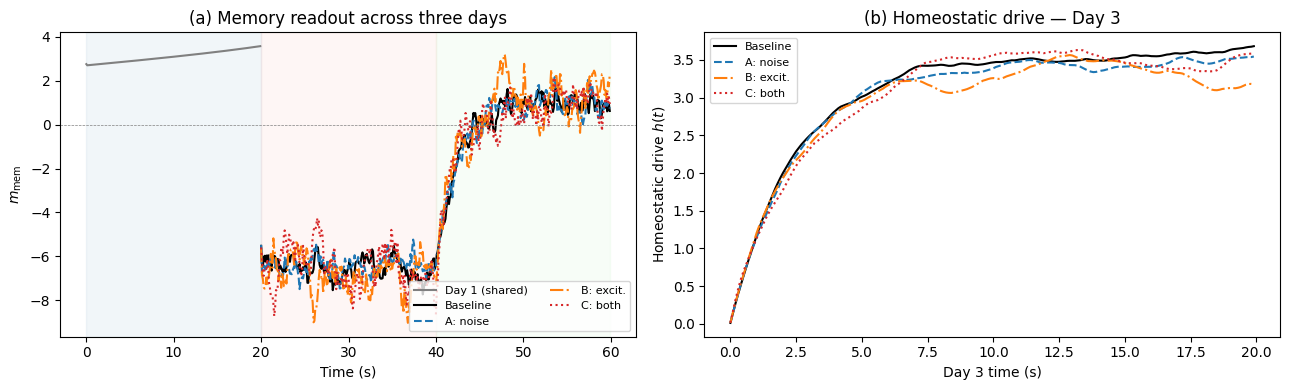

Saved fig_report2.png


In [26]:
# ============================================================
# fig_report2: m_mem across all 3 days + h(t) on Day 3
# ============================================================
base  = list(results.values())[0]
t_d2  = np.arange(len(base['r_d2'])) * REC_EVERY * dt / 1000.0
t_d3  = np.arange(len(base['r_d3'])) * REC_EVERY * dt / 1000.0
gap   = REC_EVERY * dt / 1000.0
off2  = t_d1[-1] + gap
off3  = off2 + t_d2[-1] + gap

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for cond_name, res in results.items():
    c, ls = res['color'], res['ls']
    if cond_name == 'Baseline':
        ax.plot(t_d1, res['m_mem_d1'], color='gray', lw=1.5, label='Day 1 (shared)')
    ax.plot(off2 + t_d2, res['m_mem_d2'], color=c, ls=ls, lw=1.5)
    ax.plot(off3 + t_d3, res['m_mem_d3'], color=c, ls=ls, lw=1.5, label=cond_name)

for x0, x1, col in [(0, off2, 'steelblue'), (off2, off3, 'salmon'), (off3, off3+t_d3[-1], 'lightgreen')]:
    ax.axvspan(x0, x1, alpha=0.07, color=col)

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$m_{\mathrm{mem}}$')
ax.set_title('(a) Memory readout across three days')
ax.legend(fontsize=8, loc='lower right', ncol=2)

ax2 = axes[1]
for cond_name, res in results.items():
    ax2.plot(t_d3, res['h_d3'], color=res['color'], ls=res['ls'], lw=1.5, label=cond_name)
ax2.set_xlabel('Day 3 time (s)')
ax2.set_ylabel('Homeostatic drive $h(t)$')
ax2.set_title('(b) Homeostatic drive — Day 3')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_report2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_report2.png')

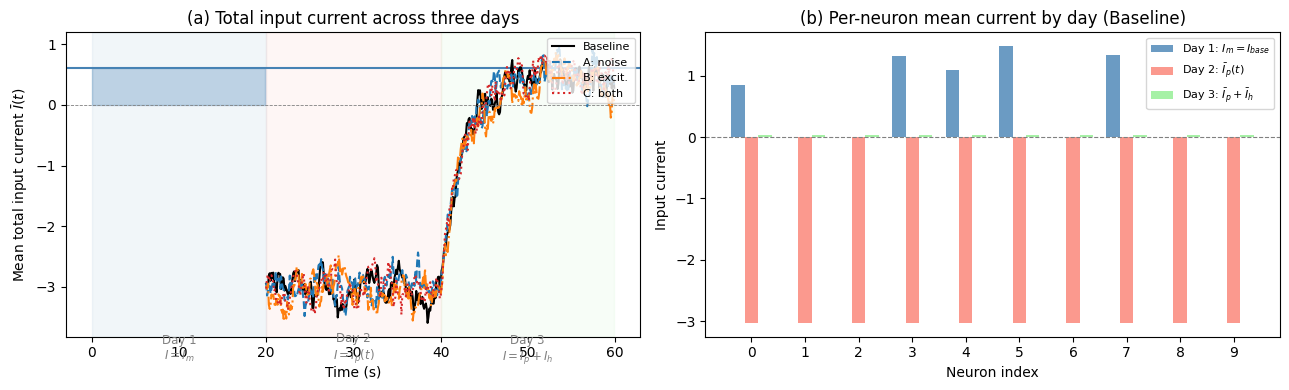

Saved fig_currents.png


In [27]:
# ============================================================
# Figure: Total input current I(t) across all three days
# Day 1: I = I_base | Day 2: I = I_p(t) | Day 3: I = I_p(t) + I_h(t)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

t_d1_plot = np.arange(len(r_d1_hist)) * REC_EVERY * dt / 1000.0
base_res = list(results.values())[0]  # Baseline for per-neuron plot
t_d2_plot = np.arange(len(base_res['I_total_d2'])) * REC_EVERY * dt / 1000.0
t_d3_plot = np.arange(len(base_res['I_total_d3'])) * REC_EVERY * dt / 1000.0
gap = REC_EVERY * dt / 1000.0
off2 = t_d1_plot[-1] + gap
off3 = off2 + t_d2_plot[-1] + gap

ax = axes[0]
# Day 1: I_base mean is constant
I_base_mean = I_base.numpy().mean()
ax.fill_between(t_d1_plot, I_base_mean, alpha=0.3, color='steelblue')
ax.axhline(I_base_mean, color='steelblue', lw=1.5, ls='-')

for cond_name, res in results.items():
    c, ls = res['color'], res['ls']
    ax.plot(off2 + t_d2_plot, res['I_total_d2'], color=c, ls=ls, lw=1.5)
    ax.plot(off3 + t_d3_plot, res['I_total_d3'], color=c, ls=ls, lw=1.5, label=cond_name)

# Day labels
for x0, x1, col, lbl in [
    (0, off2, 'steelblue', 'Day 1\n$I=I_m$'),
    (off2, off3, 'salmon', 'Day 2\n$I=I_p(t)$'),
    (off3, off3+t_d3_plot[-1], 'lightgreen', 'Day 3\n$I=I_p+I_h$'),
]:
    ax.axvspan(x0, x1, alpha=0.07, color=col)
    ax.text((x0+x1)/2, -4.2, lbl, ha='center', fontsize=8.5, color='gray')

ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'Mean total input current $\bar{I}(t)$')
ax.set_title('(a) Total input current across three days')
ax.legend(fontsize=8, loc='upper right')

# Panel b: per-neuron mean current by day (Baseline)
ax2 = axes[1]
x = np.arange(N)
width = 0.25
ax2.bar(x - width, I_base.numpy(), width, label='Day 1: $I_m = I_{base}$', color='steelblue', alpha=0.8)
ax2.bar(x, np.full(N, base_res['I_total_d2'].mean()), width, label='Day 2: $\\bar{I}_p(t)$', color='salmon', alpha=0.8)
ax2.bar(x + width, np.full(N, base_res['I_total_d3'].mean()), width, label='Day 3: $\\bar{I}_p + \\bar{I}_h$', color='lightgreen', alpha=0.8)
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_xlabel('Neuron index')
ax2.set_ylabel('Input current')
ax2.set_title('(b) Per-neuron mean current by day (Baseline)')
ax2.legend(fontsize=8)
ax2.set_xticks(x)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_currents.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_currents.png')


In [ ]:
# ============================================================
# Figure: Activity heatmaps — 4 conditions × 3 days
# ============================================================
cond_names = list(results.keys())
fig, axes = plt.subplots(4, 3, figsize=(14, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# Day 2: use fixed absolute scale so suppression is visible across all conditions
d2_vmin, d2_vmax = -4.0, 1.0

for row, cond_name in enumerate(cond_names):
    res = results[cond_name]

    # Day 1: viridis, positive rates
    im0 = axes[row, 0].imshow(r_d1_hist.T, aspect='auto', origin='lower',
                               extent=[0, t_d1[-1], -0.5, N-0.5],
                               cmap='viridis', vmin=0, vmax=r_d1_hist.max())
    axes[row, 0].set_ylabel(f'{cond_name}\nNeuron')
    if row == 0: axes[row, 0].set_title('Day 1\n$I = I_m$ (memory cue)')

    # Day 2: absolute scale — shows all neurons suppressed to ≈-3
    # Baseline/A: uniform (no ε), B/C: per-neuron variability from ε_i OU
    r_d2_data = res['r_d2']
    im1 = axes[row, 1].imshow(r_d2_data.T, aspect='auto', origin='lower',
                               extent=[0, t_d2[-1], -0.5, N-0.5],
                               cmap='coolwarm', vmin=d2_vmin, vmax=d2_vmax)
    if row == 0: axes[row, 1].set_title('Day 2\n$I = I_p(t)$ (OU, $\\mu_p=-3$)')

    # Day 3: centered per-row to show recovery pattern
    r_d3_end = res['r_d3']
    d3_mean = r_d3_end.mean()
    d3_dev  = max(np.abs(r_d3_end - d3_mean).max(), 0.05)
    im2 = axes[row, 2].imshow(r_d3_end.T, aspect='auto', origin='lower',
                               extent=[0, t_d3[-1], -0.5, N-0.5],
                               cmap='RdBu_r', vmin=d3_mean - d3_dev, vmax=d3_mean + d3_dev)
    if row == 0: axes[row, 2].set_title('Day 3\n$I = I_p(t) + I_h(t)$, homeo ON')

for ax in axes[-1]: ax.set_xlabel('Time (s)')
fig.colorbar(im0, ax=axes[:, 0], label='Rate', fraction=0.03, pad=0.04)
fig.colorbar(im1, ax=axes[:, 1], label='Rate (absolute)', fraction=0.03, pad=0.04)
fig.colorbar(im2, ax=axes[:, 2], label='Rate (centered per cond.)', fraction=0.03, pad=0.04)

plt.savefig(FIG_DIR / 'fig_activity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_activity_heatmaps.png')


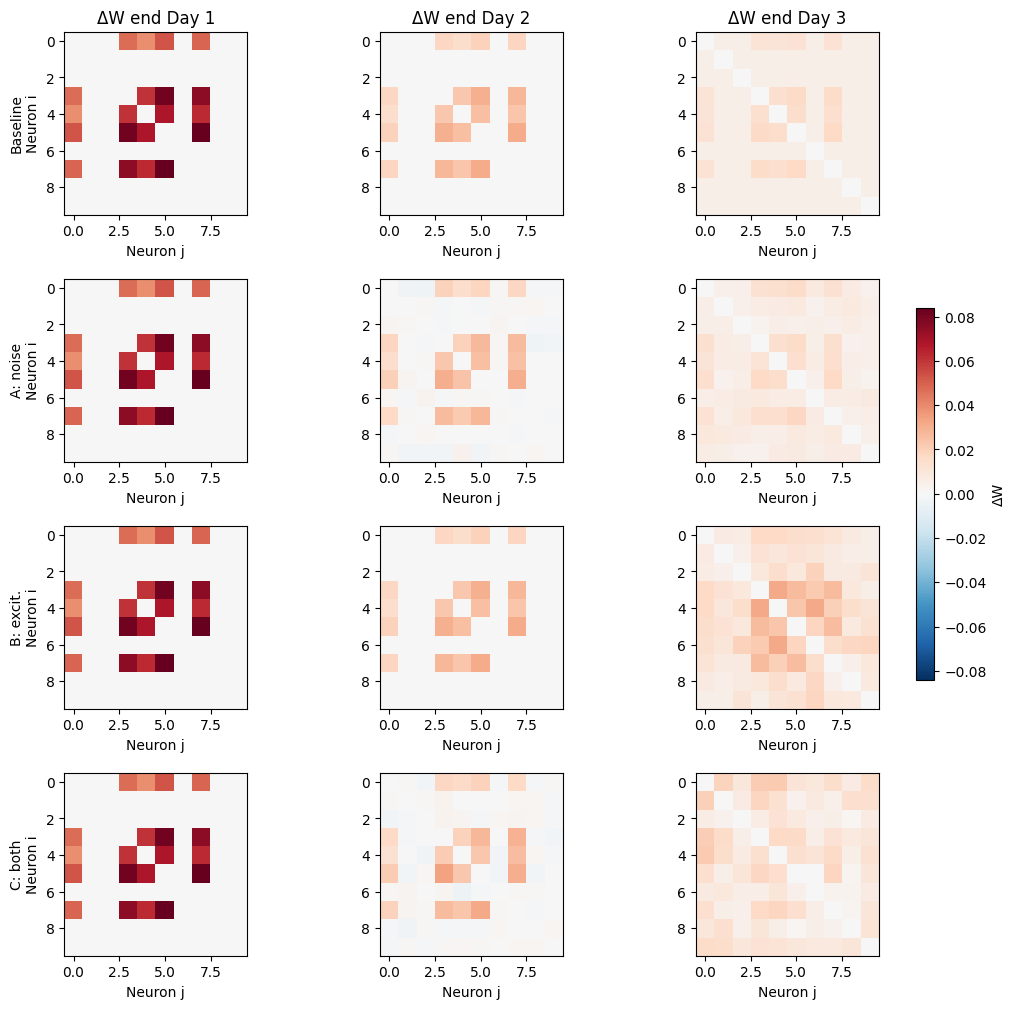

Saved fig_W_grid.png


In [29]:
# ============================================================
# Figure: Delta-W colormaps — 4 conditions × 3 days
# ============================================================
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

all_dW_vals = [dW_d1_np]
for res in results.values():
    all_dW_vals += [res['W_end_d2'] - W_struct_np, res['W_end_d3'] - W_struct_np]
vmax_dW = max(abs(m).max() for m in all_dW_vals)
vmax_dW = max(vmax_dW, 1e-6)

for row, cond_name in enumerate(cond_names):
    res = results[cond_name]

    im0 = axes[row, 0].imshow(dW_d1_np, cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    axes[row, 0].set_ylabel(f'{cond_name}\nNeuron i')
    if row == 0: axes[row, 0].set_title('\u0394W end Day 1')

    im1 = axes[row, 1].imshow(res['W_end_d2'] - W_struct_np,
                               cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    if row == 0: axes[row, 1].set_title('\u0394W end Day 2')

    im2 = axes[row, 2].imshow(res['W_end_d3'] - W_struct_np,
                               cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    if row == 0: axes[row, 2].set_title('\u0394W end Day 3')

for ax_row in axes:
    for ax in ax_row: ax.set_xlabel('Neuron j')
fig.colorbar(im2, ax=axes.ravel().tolist(), label='\u0394W', fraction=0.02, pad=0.04)
plt.savefig(FIG_DIR / 'fig_W_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_W_grid.png')

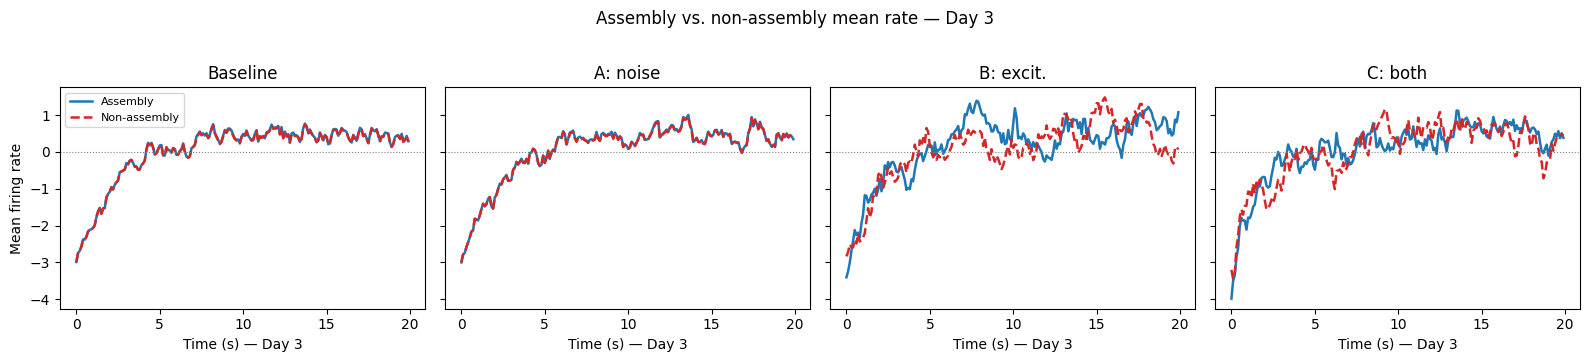

Saved fig_assembly_rates.png


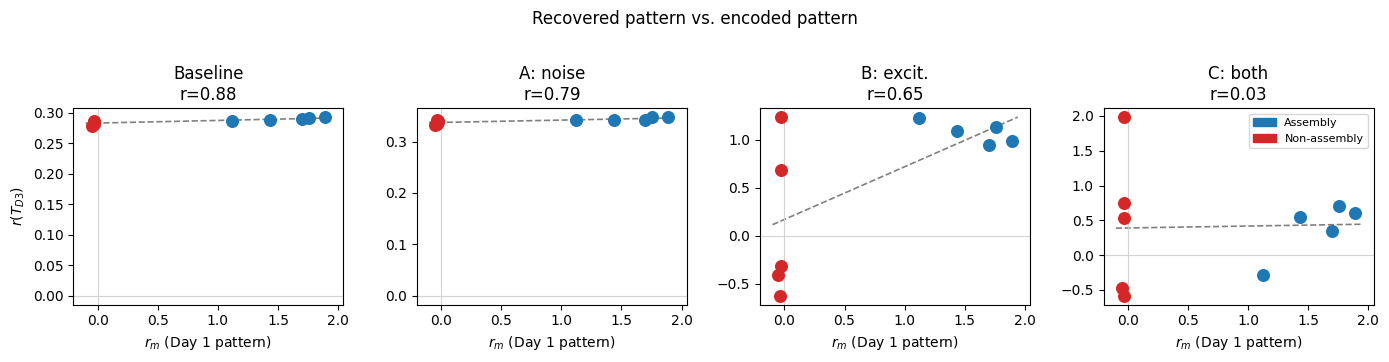

Saved fig_pattern_scatter.png


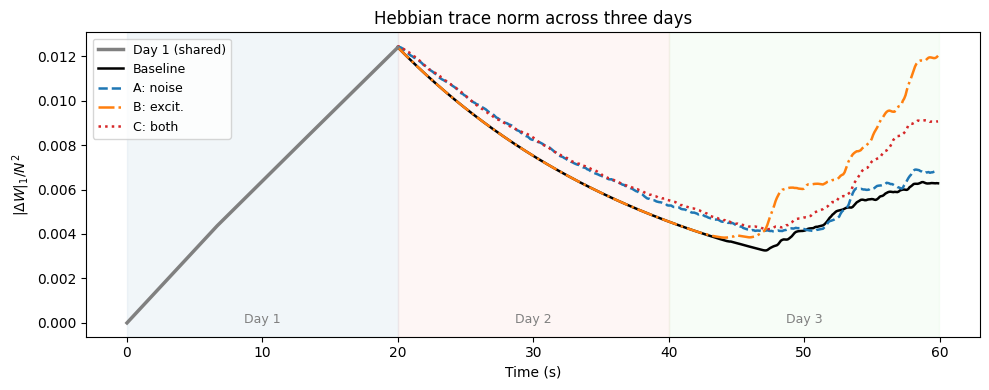

Saved fig_trace_norm.png


In [30]:
# ============================================================
# Figure 1: Assembly vs. non-assembly mean rate on Day 3
# ============================================================
assembly_idx     = [0, 3, 4, 5, 7]
non_assembly_idx = [1, 2, 6, 8, 9]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, (cond_name, res) in zip(axes, results.items()):
    r_d3  = res['r_d3']
    t_ax  = np.arange(len(r_d3)) * REC_EVERY * dt / 1000.0

    mean_asm  = r_d3[:, assembly_idx].mean(axis=1)
    mean_non  = r_d3[:, non_assembly_idx].mean(axis=1)

    ax.plot(t_ax, mean_asm,  color='tab:blue', lw=1.8, label='Assembly')
    ax.plot(t_ax, mean_non,  color='tab:red',  lw=1.8, ls='--', label='Non-assembly')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_title(cond_name)
    ax.set_xlabel('Time (s) — Day 3')
axes[0].set_ylabel('Mean firing rate')
axes[0].legend(fontsize=8)
plt.suptitle('Assembly vs. non-assembly mean rate — Day 3', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_assembly_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_assembly_rates.png')

# ============================================================
# Figure 2: Final pattern scatter r(T) vs r_m
# ============================================================
r_m_np = r_m.cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, (cond_name, res) in zip(axes, results.items()):
    r_final = res['r_d3'][-1]
    corr    = np.corrcoef(r_m_np, r_final)[0, 1]
    colors_pt = ['tab:blue' if i in assembly_idx else 'tab:red' for i in range(N)]
    for i in range(N):
        ax.scatter(r_m_np[i], r_final[i], color=colors_pt[i], s=70, zorder=3)
    m_coef, b_coef = np.polyfit(r_m_np, r_final, 1)
    xmin, xmax = r_m_np.min() - 0.05, r_m_np.max() + 0.05
    ax.plot([xmin, xmax], [m_coef*xmin+b_coef, m_coef*xmax+b_coef],
            color='gray', lw=1.2, ls='--')
    ax.axhline(0, color='lightgray', lw=0.8)
    ax.axvline(0, color='lightgray', lw=0.8)
    ax.set_title(f'{cond_name}\nr={corr:.2f}')
    ax.set_xlabel(r'$r_m$ (Day 1 pattern)')

axes[0].set_ylabel(r'$r(T_{D3})$')
from matplotlib.patches import Patch
leg = [Patch(color='tab:blue', label='Assembly'), Patch(color='tab:red', label='Non-assembly')]
axes[-1].legend(handles=leg, fontsize=8)
plt.suptitle('Recovered pattern vs. encoded pattern', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_pattern_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_pattern_scatter.png')

# ============================================================
# Figure 3: Hebbian trace norm |ΔW|_1/N^2 over all 3 days
# ============================================================
dW_d1_np = W_d1.cpu().numpy() - W_struct_np
snap_times_s = sorted(W_d1_snaps.keys())
trace_d1_arr  = np.array([np.abs(W_d1_snaps[t] - W_struct_np).mean() for t in snap_times_s])
t_d1_snaps    = np.array([t * dt / 1000.0 for t in snap_times_s])

t_d2_arr = np.arange(len(list(results.values())[0]['trace_d2'])) * REC_EVERY * dt / 1000.0
t_d3_arr = np.arange(len(list(results.values())[0]['trace_d3'])) * REC_EVERY * dt / 1000.0
off2 = t_d1_snaps[-1]
off3 = off2 + T_DAY2 * dt / 1000.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_d1_snaps, trace_d1_arr, color='gray', lw=2.5, label='Day 1 (shared)', zorder=5)

for cond_name, res in results.items():
    col = res['color']
    ls  = res['ls']
    # stitch Day1 end → Day2 → Day3
    t_full   = np.concatenate([[off2],       off2 + t_d2_arr,         off3 + t_d3_arr])
    tr_full  = np.concatenate([[trace_d1_arr[-1]], res['trace_d2'],   res['trace_d3']])
    ax.plot(t_full, tr_full, color=col, ls=ls, lw=1.8, label=cond_name)

ax.axvspan(0,    off2, alpha=0.07, color='steelblue')
ax.axvspan(off2, off3, alpha=0.07, color='salmon')
ax.axvspan(off3, off3 + T_DAY3 * dt / 1000.0, alpha=0.07, color='lightgreen')
for xv, lbl in [(off2/2, 'Day 1'), (off2 + (off3-off2)/2, 'Day 2'), (off3 + T_DAY3*dt/2000.0, 'Day 3')]:
    ax.text(xv, ax.get_ylim()[0] if False else 0, lbl, ha='center', fontsize=9, color='gray')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$|\Delta W|_1 / N^2$')
ax.set_title('Hebbian trace norm across three days')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_trace_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_trace_norm.png')


Seeds:   0%|          | 0/20 [00:00<?, ?it/s]


=== Robustness (n=20 seeds, 20-20-20 protocol) ===
  Baseline      mean=1.100  std=0.000  min=1.100  max=1.100
  A: noise      mean=1.100  std=0.002  min=1.097  max=1.105
  B: excit.     mean=0.962  std=0.744  min=-0.398  max=2.461
  C: both       mean=0.956  std=0.743  min=-0.825  max=2.346


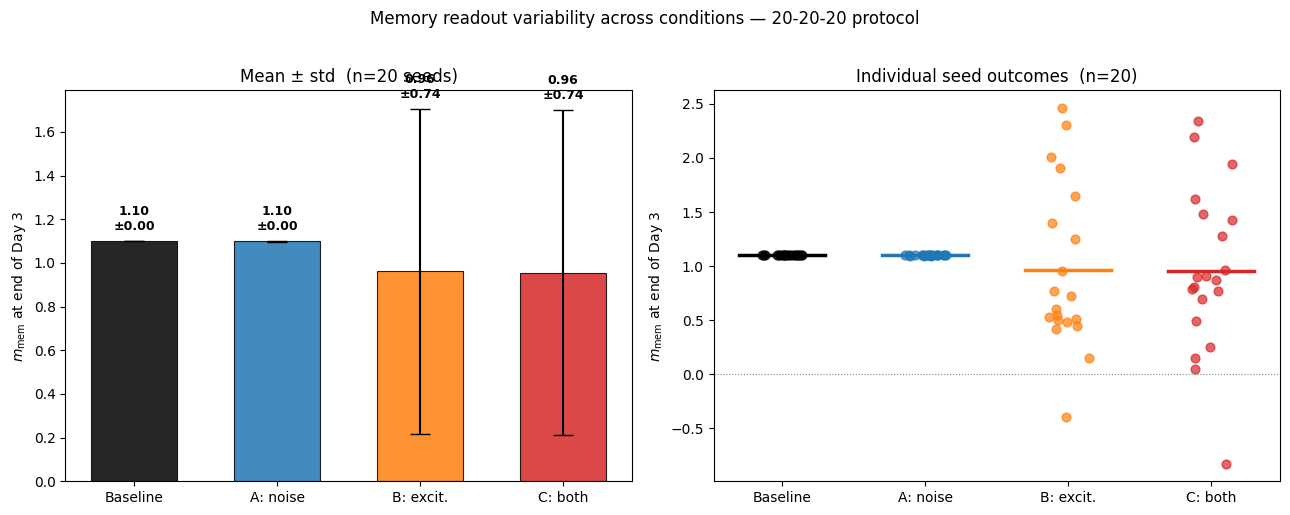

Saved fig_robustness.png


In [31]:
# ============================================================
# Robustness: m_mem over 20 random seeds (main result figure)
# Shows that Baseline and A are deterministic; B and C are stochastic
# ============================================================
N_SEEDS = 20

from collections import defaultdict
seed_results = defaultdict(list)

for s_idx in tqdm(range(N_SEEDS), desc='Seeds'):
    _net = HebbianNetwork(**PARAMS)
    # Day 1 (always seed=42 for encoding, only Days 2-3 vary)
    for t in range(T_DAY1):
        _net.step(I_base, noise_std=0.0, homeostasis=False)
    _W_d1 = _net.W.clone(); _r_d1 = _net.r.clone()
    _r_m_np = _r_d1.cpu().numpy(); _r_m_norm = np.linalg.norm(_r_m_np)

    for ci, (cond_name, params) in enumerate(CONDITIONS.items()):
        torch.manual_seed(s_idx * 100 + ci)
        np.random.seed(s_idx * 100 + ci)
        _net.W = _W_d1.clone(); _net.r = _r_d1.clone()
        _net.h = torch.tensor(0.0); _net.epsilon = torch.zeros(N)

        for t in range(T_DAY2):
            if params['use_eps']:
                drift = -_net.epsilon / TAU_EPS
                diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
                _net.epsilon = _net.epsilon + dt * drift + diff * torch.randn(N)
            _net.step(I_p, noise_std=params['noise_std'], homeostasis=False)

        for t in range(T_DAY3):
            if params['use_eps']:
                drift = -_net.epsilon / TAU_EPS
                diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
                _net.epsilon = _net.epsilon + dt * drift + diff * torch.randn(N)
            _net.step(I_p, noise_std=params['noise_std'], homeostasis=True)

        seed_results[cond_name].append(_net.r.cpu().numpy() @ _r_m_np / _r_m_norm)

# Print stats
print("\n=== Robustness (n=20 seeds, 20-20-20 protocol) ===")
for cname in CONDITIONS:
    vals = np.array(seed_results[cname])
    print(f"  {cname:12s}  mean={vals.mean():.3f}  std={vals.std():.3f}  min={vals.min():.3f}  max={vals.max():.3f}")

# Figure: bar + individual seed scatter
cond_names = list(CONDITIONS.keys())
colors = [CONDITIONS[c]['color'] for c in cond_names]
x = np.arange(len(cond_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar + error
ax = axes[0]
means = [np.mean(seed_results[c]) for c in cond_names]
stds  = [np.std(seed_results[c])  for c in cond_names]
ax.bar(x, means, 0.6, color=colors, edgecolor='k', lw=0.8,
       yerr=stds, capsize=7, error_kw={'lw': 1.5}, alpha=0.85)
ax.axhline(0, color='gray', lw=0.8, ls=':')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.05, f'{m:.2f}\n±{s:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(cond_names, fontsize=10)
ax.set_ylabel(r'$m_\mathrm{mem}$ at end of Day 3')
ax.set_title(f'Mean ± std  (n={N_SEEDS} seeds)')

# Right: individual points per seed (strip plot)
ax2 = axes[1]
np.random.seed(0)
for i, cname in enumerate(cond_names):
    vals = np.array(seed_results[cname])
    jitter = np.random.uniform(-0.15, 0.15, len(vals))
    ax2.scatter(i + jitter, vals, color=colors[i], s=40, alpha=0.7, zorder=3)
    ax2.plot([i-0.3, i+0.3], [vals.mean(), vals.mean()], color=colors[i], lw=2.5, zorder=4)
ax2.axhline(0, color='gray', lw=0.8, ls=':')
ax2.set_xticks(x); ax2.set_xticklabels(cond_names, fontsize=10)
ax2.set_ylabel(r'$m_\mathrm{mem}$ at end of Day 3')
ax2.set_title(f'Individual seed outcomes  (n={N_SEEDS})')

plt.suptitle('Memory readout variability across conditions — 20-20-20 protocol', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_robustness.png')


Saved fig_robustness.png


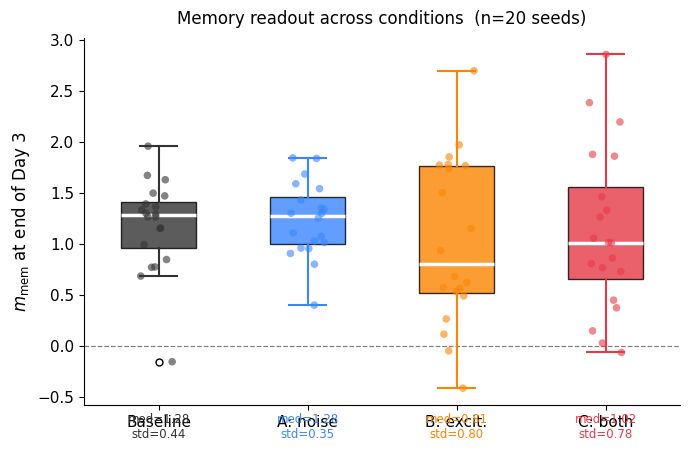

In [32]:
N=10; dt=10.0
PARAMS = dict(N=N,dt=dt,tau_r=10.0,tau_W=2000.0,tau_h=500.0,eta=0.005,lam=0.1,kappa_h=0.2,m_target=0.5,W_scale=0.1,seed=42)
NOISE_STD=0.01; TAU_EPS=1000.0; SIGMA_EPS=0.8
FIG_DIR = Path('/Users/elenaegorova/Library/Mobile Documents/com~apple~CloudDocs/PhD/Computational Neuroscience/project/representational-drift/figures')
I_base = torch.tensor(np.load('/Users/elenaegorova/Library/Mobile Documents/com~apple~CloudDocs/PhD/Computational Neuroscience/project/representational-drift/data/I_base.npy'), dtype=torch.float32)
MU_P    = -3.0
TAU_P   = 500.0
SIGMA_P = 0.2
T_DAY1=T_DAY2=T_DAY3=2000

CONDITIONS = {
    'Baseline':  {'noise_std': 0.0,       'use_eps': False, 'color': '#333333'},
    'A: noise':  {'noise_std': NOISE_STD,  'use_eps': False, 'color': '#3a86ff'},
    'B: excit.': {'noise_std': 0.0,        'use_eps': True,  'color': '#fb8500'},
    'C: both':   {'noise_std': NOISE_STD,  'use_eps': True,  'color': '#e63946'},
}

# Day 1 (deterministic)
net = HebbianNetwork(**PARAMS)
for t in range(T_DAY1):
    net.step(I_base, noise_std=0.0, homeostasis=False)
W_d1 = net.W.clone(); r_d1 = net.r.clone()
r_m_np = r_d1.cpu().numpy(); r_m_norm = np.linalg.norm(r_m_np)

N_SEEDS = 20
from collections import defaultdict
seed_results = defaultdict(list)

for s_idx in range(N_SEEDS):
    for ci, (cname, params) in enumerate(CONDITIONS.items()):
        torch.manual_seed(s_idx * 100 + ci)
        np.random.seed(s_idx * 100 + ci)
        net.W=W_d1.clone(); net.r=r_d1.clone(); net.h=torch.tensor(0.0); net.epsilon=torch.zeros(N)
        I_p_s = float(MU_P)
        for t in range(T_DAY2):
            I_p_s += dt*(-(I_p_s-MU_P)/TAU_P) + SIGMA_P*(2.0*dt/TAU_P)**0.5*np.random.randn()
            I_p_curr = torch.full((N,), float(I_p_s))
            if params['use_eps']:
                net.epsilon = net.epsilon + dt*(-net.epsilon/TAU_EPS) + SIGMA_EPS*(2*dt/TAU_EPS)**0.5*torch.randn(N)
            net.step(I_p_curr, noise_std=params['noise_std'], homeostasis=False)
        for t in range(T_DAY3):
            I_p_s += dt*(-(I_p_s-MU_P)/TAU_P) + SIGMA_P*(2.0*dt/TAU_P)**0.5*np.random.randn()
            I_p_curr = torch.full((N,), float(I_p_s))
            if params['use_eps']:
                net.epsilon = net.epsilon + dt*(-net.epsilon/TAU_EPS) + SIGMA_EPS*(2*dt/TAU_EPS)**0.5*torch.randn(N)
            net.step(I_p_curr, noise_std=params['noise_std'], homeostasis=True)
        seed_results[cname].append(net.r.cpu().numpy() @ r_m_np / r_m_norm)

cond_names = list(CONDITIONS.keys())
data = [seed_results[c] for c in cond_names]
colors = [CONDITIONS[c]['color'] for c in cond_names]

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(data, positions=range(len(cond_names)),
                widths=0.5, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=5, linestyle='none'))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for whisker, cap, color in zip(bp['whiskers'][::2], bp['caps'][::2], colors):
    whisker.set_color(color)
    cap.set_color(color)
for whisker, cap, color in zip(bp['whiskers'][1::2], bp['caps'][1::2], colors):
    whisker.set_color(color)
    cap.set_color(color)

# Overlay individual points with jitter
np.random.seed(1)
for i, (vals, color) in enumerate(zip(data, colors)):
    jitter = np.random.uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, s=30, alpha=0.6, zorder=4, edgecolors='none')

ax.axhline(0, color='gray', lw=0.9, ls='--', zorder=1)
ax.set_xticks(range(len(cond_names)))
ax.set_xticklabels(cond_names, fontsize=12)
ax.set_ylabel(r'$m_\mathrm{mem}$ at end of Day 3', fontsize=12)
ax.set_title(f'Memory readout across conditions  (n={N_SEEDS} seeds)', fontsize=12, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

# Annotate median and std below x-axis
for i, (cname, vals) in enumerate(zip(cond_names, data)):
    vals = np.array(vals)
    ax.text(i, ax.get_ylim()[0] - 0.08,
            f'med={np.median(vals):.2f}\nstd={vals.std():.2f}',
            ha='center', va='top', fontsize=8.5, color=colors[i])

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(FIG_DIR / 'fig_robustness.png', dpi=150, bbox_inches='tight')
print("Saved fig_robustness.png")

In [33]:
# ============================================================
# Summary statistics
# ============================================================
print('=== Final Summary ===')
print(f'Day 1:  r_m mean = {r_m.mean():.3f},  \u0394W L1/N^2 = {np.abs(dW_d1_np).mean():.5f}')
print()
for cond_name, res in results.items():
    dW_d2  = res['W_end_d2'] - W_struct_np
    dW_d3  = res['W_end_d3'] - W_struct_np
    t1     = np.abs(dW_d1_np).mean()
    pct_d2 = 100 * np.abs(dW_d2).mean() / t1 if t1 > 0 else 0
    pct_d3 = 100 * np.abs(dW_d3).mean() / t1 if t1 > 0 else 0
    print(f'{cond_name:12s}  '
          f'm_mem D3_end={res["m_mem_d3"][-1]:.3f}  '
          f'h D3_end={res["h_d3"][-1]:.3f}  '
          f'trace: D2={pct_d2:.0f}%  D3={pct_d3:.0f}%')

=== Final Summary ===
Day 1:  r_m mean = 0.773,  ΔW L1/N^2 = 0.01239

Baseline      m_mem D3_end=0.625  h D3_end=3.681  trace: D2=37%  D3=51%
A: noise      m_mem D3_end=0.743  h D3_end=3.544  trace: D2=43%  D3=55%
B: excit.     m_mem D3_end=2.340  h D3_end=3.178  trace: D2=37%  D3=97%
C: both       m_mem D3_end=0.940  h D3_end=3.585  trace: D2=45%  D3=73%


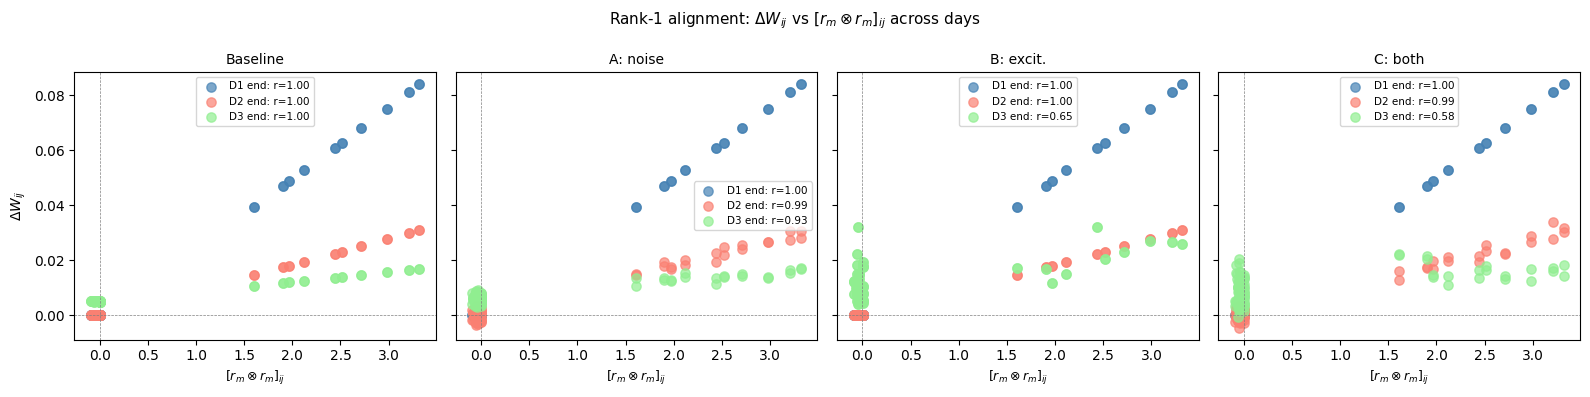

Saved fig_corr_rank1.png

=== Rank-1 alignment: corr(ΔW_ij, r_m_i * r_m_j) ===
  Baseline        D1: r = 1.000
  Baseline        D2: r = 1.000
  Baseline        D3: r = 0.999

  A: noise        D1: r = 1.000
  A: noise        D2: r = 0.990
  A: noise        D3: r = 0.926

  B: excit.       D1: r = 1.000
  B: excit.       D2: r = 1.000
  B: excit.       D3: r = 0.646

  C: both         D1: r = 1.000
  C: both         D2: r = 0.985
  C: both         D3: r = 0.576

Running cross-seed correlation (B and C conditions, 20 seeds)...


Cross-seed corr:   0%|          | 0/20 [00:00<?, ?it/s]

B: excit.: rank-1 at D2 → m_mem at D3: r = 0.000
C: both: rank-1 at D2 → m_mem at D3: r = -0.403


/var/folders/0w/46xzhnf976ld60ynxfgwjqpr0000gn/T/ipykernel_92029/2766924529.py:101: RankWarning: Polyfit may be poorly conditioned
  m_c, b_c = np.polyfit(x, y, 1)


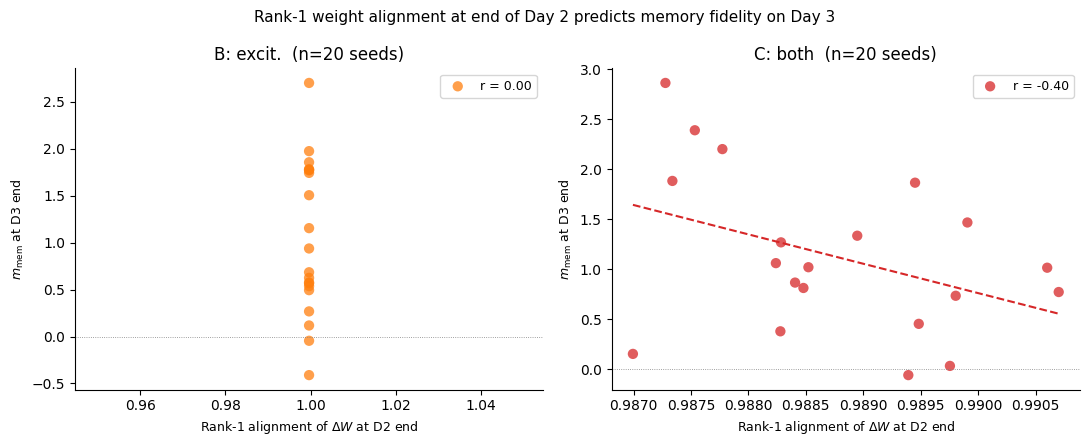

Saved fig_corr_seeds.png


In [34]:
# ============================================================
# Correlation analysis: ΔW structure vs m_mem
# 1. Rank-1 alignment of ΔW with r_m ⊗ r_m across days/conditions
# 2. Cross-seed: rank-1 alignment at D2 end vs m_mem at D3 end
# ============================================================
r_m_np = r_m.cpu().numpy()
r_m_norm = np.linalg.norm(r_m_np)
outer_rm = np.outer(r_m_np, r_m_np)
outer_flat = outer_rm.flatten()
mask_off_diag = ~np.eye(N, dtype=bool).flatten()

# --- Figure 1: rank-1 scatter per condition ---
fig, axes_r1 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
cond_names_list = list(results.keys())

for ax, cond_name in zip(axes_r1, cond_names_list):
    res = results[cond_name]
    for dW_data, day_label, color in [
        (dW_d1_np,                    'D1 end', 'steelblue'),
        (res['W_end_d2']-W_struct_np, 'D2 end', 'salmon'),
        (res['W_end_d3']-W_struct_np, 'D3 end', 'lightgreen'),
    ]:
        dW_flat = dW_data.flatten()[mask_off_diag]
        corr = np.corrcoef(dW_flat, outer_flat[mask_off_diag])[0, 1]
        ax.scatter(outer_flat[mask_off_diag], dW_flat,
                   color=color, alpha=0.7, s=45, label=f'{day_label}: r={corr:.2f}')
    ax.set_xlabel(r'$[r_m \otimes r_m]_{ij}$', fontsize=9)
    ax.set_title(cond_name, fontsize=10)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.legend(fontsize=7.5)

axes_r1[0].set_ylabel(r'$\Delta W_{ij}$')
plt.suptitle(r'Rank-1 alignment: $\Delta W_{ij}$ vs $[r_m \otimes r_m]_{ij}$ across days', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_corr_rank1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_corr_rank1.png')

# --- Print rank-1 summary ---
print('\n=== Rank-1 alignment: corr(ΔW_ij, r_m_i * r_m_j) ===')
for cond_name in cond_names_list:
    res = results[cond_name]
    for dW_data, day_label in [
        (dW_d1_np,                    'D1'),
        (res['W_end_d2']-W_struct_np, 'D2'),
        (res['W_end_d3']-W_struct_np, 'D3'),
    ]:
        dW_flat = dW_data.flatten()[mask_off_diag]
        corr = np.corrcoef(dW_flat, outer_flat[mask_off_diag])[0, 1]
        print(f'  {cond_name:14s}  {day_label}: r = {corr:.3f}')
    print()

# --- Cross-seed analysis: rank-1 alignment at D2 vs m_mem at D3 ---
print('Running cross-seed correlation (B and C conditions, 20 seeds)...')
seed_rank1_d2_B = []; seed_mmem_d3_B = []
seed_rank1_d2_C = []; seed_mmem_d3_C = []

for s_idx in tqdm(range(N_SEEDS), desc='Cross-seed corr'):
    for ci, (cname, params) in enumerate(CONDITIONS.items()):
        if cname not in ('B: excit.', 'C: both'):
            continue
        torch.manual_seed(s_idx * 100 + ci)
        np.random.seed(s_idx * 100 + ci)
        net.W = W_d1.clone(); net.r = r_d1_final.clone()
        net.h = torch.tensor(0.0); net.epsilon = torch.zeros(N)
        I_p_s = float(MU_P)

        for t in range(T_DAY2):
            I_p_s += dt * (-(I_p_s - MU_P) / TAU_P) + SIGMA_P * (2.0*dt/TAU_P)**0.5 * np.random.randn()
            I_p_curr = torch.full((N,), float(I_p_s))
            if params['use_eps']:
                net.epsilon += dt * (-net.epsilon / TAU_EPS) + SIGMA_EPS*(2*dt/TAU_EPS)**0.5*torch.randn(N)
            net.step(I_p_curr, noise_std=params['noise_std'], homeostasis=False)

        dW_d2_s = net.W.cpu().numpy() - W_struct_np
        dW_flat_s = dW_d2_s.flatten()[mask_off_diag]
        r1 = np.corrcoef(dW_flat_s, outer_flat[mask_off_diag])[0, 1]

        for t in range(T_DAY3):
            I_p_s += dt * (-(I_p_s - MU_P) / TAU_P) + SIGMA_P * (2.0*dt/TAU_P)**0.5 * np.random.randn()
            I_p_curr = torch.full((N,), float(I_p_s))
            if params['use_eps']:
                net.epsilon += dt * (-net.epsilon / TAU_EPS) + SIGMA_EPS*(2*dt/TAU_EPS)**0.5*torch.randn(N)
            net.step(I_p_curr, noise_std=params['noise_std'], homeostasis=True)

        mmem = net.r.cpu().numpy() @ r_m_np / r_m_norm
        if cname == 'B: excit.':
            seed_rank1_d2_B.append(r1); seed_mmem_d3_B.append(mmem)
        else:
            seed_rank1_d2_C.append(r1); seed_mmem_d3_C.append(mmem)

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))
for ax2, (r1_list, mm_list, cname, color) in zip(axes2, [
    (seed_rank1_d2_B, seed_mmem_d3_B, 'B: excit.', 'tab:orange'),
    (seed_rank1_d2_C, seed_mmem_d3_C, 'C: both',   'tab:red'),
]):
    x = np.array(r1_list); y = np.array(mm_list)
    r = np.corrcoef(x, y)[0, 1]
    ax2.scatter(x, y, color=color, s=55, alpha=0.75, edgecolors='none', label=f'r = {r:.2f}')
    m_c, b_c = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 50)
    ax2.plot(x_line, m_c*x_line + b_c, color=color, lw=1.5, ls='--')
    ax2.axhline(0, color='gray', lw=0.6, ls=':')
    ax2.set_xlabel(r'Rank-1 alignment of $\Delta W$ at D2 end', fontsize=9)
    ax2.set_ylabel(r'$m_\mathrm{mem}$ at D3 end', fontsize=9)
    ax2.set_title(f'{cname}  (n={N_SEEDS} seeds)')
    ax2.legend(fontsize=9)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    print(f'{cname}: rank-1 at D2 → m_mem at D3: r = {r:.3f}')

plt.suptitle('Rank-1 weight alignment at end of Day 2 predicts memory fidelity on Day 3', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_corr_seeds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_corr_seeds.png')
